In [1]:
# ============================================================
# CELL 1: IMPORT THƯ VIỆN VÀ CẤU HÌNH CHUNG
# ============================================================

import os
import gc
import json
import math
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Seed cố định
# ------------------------------------------------------------
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/notebook03_ijepa_pretrain")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUTPUT_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)


Device: cuda
GPU: Tesla T4
CUDA version: 12.8
OUTPUT_DIR: /kaggle/working/notebook03_ijepa_pretrain


In [2]:
# ============================================================
# CELL 2: IMPORT HOẶC CÀI TIMM
# ============================================================

try:
    import timm
    print("timm imported successfully.")
except ImportError:
    print("timm chưa có. Đang cài đặt...")
    !pip install -q timm
    import timm
    print("timm installed and imported successfully.")

print("timm version:", timm.__version__)


timm imported successfully.
timm version: 1.0.25


In [3]:
# ============================================================
# CELL 3: TÌM METADATA NIH TỪ NOTEBOOK 01
# ============================================================

INPUT_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")

def find_file_everywhere(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None

NIH_30K_CSV = find_file_everywhere("nih_pretrain_30k.csv")
NIH_50K_CSV = find_file_everywhere("nih_pretrain_50k.csv")

print("NIH_30K_CSV:", NIH_30K_CSV)
print("NIH_50K_CSV:", NIH_50K_CSV)

assert NIH_30K_CSV is not None, "Không tìm thấy nih_pretrain_30k.csv. Hãy add output Notebook 01."
assert NIH_50K_CSV is not None, "Không tìm thấy nih_pretrain_50k.csv. Hãy add output Notebook 01."

print("Đã tìm thấy metadata NIH.")


NIH_30K_CSV: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/nih_pretrain_30k.csv
NIH_50K_CSV: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/nih_pretrain_50k.csv
Đã tìm thấy metadata NIH.


In [4]:
# ============================================================
# CELL 4: CHỌN NIH SUBSET CHO PRETRAINING
# ============================================================

USE_SUBSET = "50k"   # "30k" hoặc "50k"

if USE_SUBSET == "30k":
    nih_csv_path = NIH_30K_CSV
elif USE_SUBSET == "50k":
    nih_csv_path = NIH_50K_CSV
else:
    raise ValueError("USE_SUBSET phải là '30k' hoặc '50k'.")

nih_df = pd.read_csv(nih_csv_path)

print("Using NIH subset:", USE_SUBSET)
print("Metadata path:", nih_csv_path)
print("NIH metadata shape:", nih_df.shape)
display(nih_df.head())


Using NIH subset: 50k
Metadata path: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/nih_pretrain_50k.csv
NIH metadata shape: (50000, 1)


,image_path
0,/kaggle/input/datasets/khanfashee/nih-chest-x-...
1,/kaggle/input/datasets/khanfashee/nih-chest-x-...
2,/kaggle/input/datasets/khanfashee/nih-chest-x-...
3,/kaggle/input/datasets/khanfashee/nih-chest-x-...
4,/kaggle/input/datasets/khanfashee/nih-chest-x-...


In [5]:
# ============================================================
# CELL 5: KIỂM TRA VÀ SỬA ĐƯỜNG DẪN ẢNH NIH NẾU CẦN
# ============================================================

def count_missing_images(df):
    return (~df["image_path"].apply(lambda x: Path(x).exists())).sum()

missing_before = count_missing_images(nih_df)
print("Missing images before fix:", missing_before)

if missing_before > 0:
    print("Đang xây index ảnh từ /kaggle/input...")
    image_exts = [".png", ".jpg", ".jpeg"]
    all_nih_images = []
    for ext in image_exts:
        all_nih_images.extend(list(INPUT_ROOT.rglob(f"*{ext}")))
    print("Total images found:", len(all_nih_images))

    filename_to_path = {p.name: str(p) for p in all_nih_images}

    def fix_path(old_path):
        fname = Path(old_path).name
        return filename_to_path.get(fname, None)

    nih_df["image_path"] = nih_df["image_path"].apply(fix_path)
    nih_df = nih_df.dropna(subset=["image_path"]).reset_index(drop=True)

missing_after = count_missing_images(nih_df)
print("NIH rows after path fix:", len(nih_df))
print("Missing images after fix:", missing_after)
assert missing_after == 0, "Vẫn còn ảnh NIH bị missing!"
display(nih_df.head())


Missing images before fix: 0
NIH rows after path fix: 50000
Missing images after fix: 0


,image_path
0,/kaggle/input/datasets/khanfashee/nih-chest-x-...
1,/kaggle/input/datasets/khanfashee/nih-chest-x-...
2,/kaggle/input/datasets/khanfashee/nih-chest-x-...
3,/kaggle/input/datasets/khanfashee/nih-chest-x-...
4,/kaggle/input/datasets/khanfashee/nih-chest-x-...


In [6]:
# ============================================================
# CELL 6: KIỂM TRA ĐỌC ẢNH NIH
# ============================================================

sample_paths = nih_df["image_path"].sample(n=5, random_state=SEED).tolist()
for p in sample_paths:
    img = Image.open(p).convert("RGB")
    print(Path(p).name, "mode:", img.mode, "size:", img.size)


00019369_007.png mode: RGB size: (224, 224)
00011956_006.png mode: RGB size: (224, 224)
00009604_005.png mode: RGB size: (224, 224)
00001200_001.png mode: RGB size: (224, 224)
00003973_009.png mode: RGB size: (224, 224)


In [7]:
# ============================================================
# CELL 7: TRANSFORM CHO NIH PRETRAINING
# ============================================================

IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

pretrain_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=7),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Pretrain transform ready.")


Pretrain transform ready.


In [8]:
# ============================================================
# CELL 8: DATASET CLASS CHO NIH KHÔNG NHÃN
# ============================================================

class NIHCXRPretrainDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return {"image": image, "image_path": row["image_path"]}


In [9]:
# ============================================================
# CELL 9: TẠO DATALOADER NIH
# ============================================================

BATCH_SIZE   = 32
NUM_WORKERS  = 2

nih_dataset = NIHCXRPretrainDataset(nih_df, transform=pretrain_transform)

nih_loader = DataLoader(
    nih_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

print("NIH dataset size:", len(nih_dataset))
print("NIH batches:", len(nih_loader))


NIH dataset size: 50000
NIH batches: 1562


In [10]:
# ============================================================
# CELL 10: TEST MỘT BATCH NIH
# ============================================================

batch = next(iter(nih_loader))
print("Image batch shape:", batch["image"].shape)
print("Example path:", batch["image_path"][0])


Image batch shape: torch.Size([32, 3, 224, 224])
Example path: /kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224/00008464_001.png


In [11]:
# ============================================================
# CELL 11: HÀM TẠO MASK CHO PATCHES
# ============================================================

PATCH_SIZE            = 16
NUM_PATCHES_PER_SIDE  = IMG_SIZE // PATCH_SIZE
NUM_PATCHES           = NUM_PATCHES_PER_SIDE * NUM_PATCHES_PER_SIDE  # 196

def generate_random_patch_mask(batch_size, num_patches=196, mask_ratio=0.75, device="cpu"):
    """
    Tạo boolean mask: True = patch bị mask (target cần predict).
    mask_ratio=0.75 theo paper I-JEPA gốc.
    """
    num_masked = int(num_patches * mask_ratio)
    masks = torch.zeros(batch_size, num_patches, dtype=torch.bool)
    for i in range(batch_size):
        idx = torch.randperm(num_patches)[:num_masked]
        masks[i, idx] = True
    return masks.to(device)

# Kiểm tra
test_mask = generate_random_patch_mask(batch_size=4, num_patches=NUM_PATCHES, mask_ratio=0.75)
print("Mask shape:", test_mask.shape)
print("Masked patches per image:", test_mask.sum(dim=1))


Mask shape: torch.Size([4, 196])
Masked patches per image: tensor([147, 147, 147, 147])


In [12]:
# ============================================================
# CELL 12: TẠO VIT-SMALL/16 ENCODER
# ============================================================

def build_vit_small_encoder(pretrained=False):
    """ViT-Small/16 — num_classes=0 bỏ classification head."""
    model = timm.create_model(
        "vit_small_patch16_224",
        pretrained=pretrained,
        num_classes=0
    )
    return model

# Student / context encoder
student_encoder = build_vit_small_encoder(pretrained=False)

# Target encoder — khởi tạo giống student, update bằng EMA
target_encoder = build_vit_small_encoder(pretrained=False)
target_encoder.load_state_dict(student_encoder.state_dict())
for p in target_encoder.parameters():
    p.requires_grad = False

EMBED_DIM = student_encoder.num_features

print("ViT-Small/16 encoder created.")
print("Embedding dim:", EMBED_DIM)
print("Num patches:", NUM_PATCHES)


ViT-Small/16 encoder created.
Embedding dim: 384
Num patches: 196


In [13]:
# ============================================================
# CELL 13: HÀM LẤY PATCH TOKENS TỪ VIT
# ============================================================

def get_patch_tokens(vit_model, images):
    """
    Trả về patch tokens từ ViT, shape [B, 196, D].
    Bỏ CLS token nếu có.
    """
    features = vit_model.forward_features(images)
    if isinstance(features, torch.Tensor):
        if features.dim() == 3 and features.shape[1] == NUM_PATCHES + 1:
            return features[:, 1:, :]   # bỏ CLS token
        elif features.dim() == 3 and features.shape[1] == NUM_PATCHES:
            return features
        else:
            raise ValueError(f"Unexpected ViT features shape: {features.shape}")
    raise ValueError("Unexpected features type.")

# Test
student_encoder = student_encoder.to(DEVICE)
target_encoder  = target_encoder.to(DEVICE)

test_images = batch["image"][:4].to(DEVICE)
with torch.no_grad():
    test_tokens = get_patch_tokens(student_encoder, test_images)
print("Patch tokens shape:", test_tokens.shape)  # expect [4, 196, 384]


Patch tokens shape: torch.Size([4, 196, 384])


In [14]:
# ============================================================
# CELL 14: PREDICTOR — NARROW VIT (CÓ POSITIONAL ENCODING)
# ============================================================
# Paper gốc I-JEPA dùng narrow Transformer làm predictor
# để mô hình biết đang predict token ở VỊ TRÍ nào.
# Đây là cải tiến quan trọng so với MLP.

class IJEPAPredictor(nn.Module):
    """
    Narrow Transformer predictor theo I-JEPA paper.
    Encode positional information + predict target tokens.
    """
    def __init__(self, embed_dim=384, predictor_dim=192, num_heads=4, num_layers=4):
        super().__init__()
        self.input_proj  = nn.Linear(embed_dim, predictor_dim)
        self.pos_embed   = nn.Parameter(torch.zeros(1, NUM_PATCHES, predictor_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=num_heads,
            dim_feedforward=predictor_dim * 4,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(predictor_dim, embed_dim)
        self.norm        = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: [B, 196, embed_dim]
        x = self.input_proj(x)              # [B, 196, predictor_dim]
        x = x + self.pos_embed             # add positional info
        x = self.transformer(x)            # [B, 196, predictor_dim]
        x = self.output_proj(x)            # [B, 196, embed_dim]
        x = self.norm(x)
        return x

predictor = IJEPAPredictor(
    embed_dim=EMBED_DIM,
    predictor_dim=192,
    num_heads=4,
    num_layers=4
).to(DEVICE)

total_params = sum(p.numel() for p in predictor.parameters() if p.requires_grad)
print(f"Predictor ready | trainable params: {total_params:,}")


Predictor ready | trainable params: 1,965,888


/tmp/ipykernel_22/2776207895.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [15]:
# ============================================================
# CELL 15: EMA UPDATE CHO TARGET ENCODER
# ============================================================

@torch.no_grad()
def update_target_encoder_ema(student_encoder, target_encoder, momentum=0.996):
    """Cập nhật target encoder bằng exponential moving average."""
    for s_param, t_param in zip(student_encoder.parameters(), target_encoder.parameters()):
        t_param.data.mul_(momentum).add_(s_param.data, alpha=1.0 - momentum)


In [16]:
# ============================================================
# CELL 16: I-JEPA LOSS — ĐÃ SỬA ĐÚNG THEO PAPER
# ============================================================
#
# SỬA LỖI QUAN TRỌNG SO VỚI NOTEBOOK CŨ:
#
#   ❌ Cũ: apply_patch_mask_to_images() — zero-out pixel trước khi
#          cho vào encoder. Encoder học bỏ qua vùng 0 thay vì học
#          predict latent representation.
#
#   ✅ Mới: Context encoder nhìn TOÀN BỘ ảnh gốc (không mask pixel).
#           Chỉ tính loss trên token của các patch bị mask.
#           Đây là cách I-JEPA paper thực sự hoạt động.
#
#   ❌ Cũ: mask_expanded reshape flatten — dễ lỗi shape khi
#          num_masked không đồng đều.
#
#   ✅ Mới: Loop per-sample để tính loss chính xác từng ảnh.
# ============================================================

def ijepa_loss(
    student_encoder,
    target_encoder,
    predictor,
    images,
    mask_ratio=0.75
):
    """
    Tính I-JEPA loss đúng theo paper.

    Args:
        images: [B, C, H, W] — ảnh gốc, không bị mask pixel
        mask_ratio: tỷ lệ patches bị mask (default 0.75 theo paper)

    Returns:
        scalar loss
    """
    B = images.size(0)

    # 1. Tạo mask: True = patch bị mask (target)
    patch_mask = generate_random_patch_mask(
        batch_size=B,
        num_patches=NUM_PATCHES,
        mask_ratio=mask_ratio,
        device=images.device
    )

    # 2. ✅ Context encoder nhìn TOÀN BỘ ảnh gốc (không zero-out pixel)
    student_patch_tokens = get_patch_tokens(student_encoder, images)
    # [B, 196, D]

    # 3. Target encoder cũng nhìn toàn bộ ảnh gốc, không gradient
    with torch.no_grad():
        target_patch_tokens = get_patch_tokens(target_encoder, images)
        # Normalize target theo paper
        target_patch_tokens = F.layer_norm(
            target_patch_tokens,
            normalized_shape=(target_patch_tokens.shape[-1],)
        )
    # [B, 196, D]

    # 4. Predictor dự đoán token của tất cả patches
    pred_patch_tokens = predictor(student_patch_tokens)
    # [B, 196, D]

    # 5. ✅ Tính loss per-sample trên masked patches
    total_loss = 0.0
    for i in range(B):
        mask_i   = patch_mask[i]           # [196] bool
        pred_i   = pred_patch_tokens[i][mask_i]    # [num_masked, D]
        target_i = target_patch_tokens[i][mask_i]  # [num_masked, D]
        total_loss += F.mse_loss(pred_i, target_i)

    return total_loss / B


In [17]:
# ============================================================
# CELL 17: TEST FORWARD LOSS
# ============================================================

student_encoder.train()
predictor.train()
target_encoder.eval()

test_batch  = next(iter(nih_loader))
test_images = test_batch["image"].to(DEVICE)

with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
    test_loss = ijepa_loss(
        student_encoder=student_encoder,
        target_encoder=target_encoder,
        predictor=predictor,
        images=test_images,
        mask_ratio=0.75
    )

print("Test I-JEPA loss (mask_ratio=0.75):", float(test_loss.detach().cpu()))
print("Loss sẽ cao hơn notebook cũ vì mask_ratio tăng từ 0.4 → 0.75 (đúng hơn)")


/tmp/ipykernel_22/1807391207.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Test I-JEPA loss (mask_ratio=0.75): 1.9766782522201538
Loss sẽ cao hơn notebook cũ vì mask_ratio tăng từ 0.4 → 0.75 (đúng hơn)


In [18]:
# ============================================================
# CELL 18: CẤU HÌNH PRETRAINING (ĐÃ CẬP NHẬT)
# ============================================================

# ── Thay đổi so với notebook cũ ──────────────────────────────
# PRETRAIN_EPOCHS: 50  (cũ: 20 — loss chưa hội tụ)
# MASK_RATIO: 0.75     (cũ: 0.40 — quá thấp, bài toán quá dễ)
# LR scheduler: cosine decay + warmup  (cũ: không có)
# ─────────────────────────────────────────────────────────────

PRETRAIN_EPOCHS    = 50        # Tổng epochs muốn chạy
WARMUP_EPOCHS      = 3         # Warmup LR từ 0 → LR_MAX
LR_MAX             = 1e-4      # Peak learning rate
LR_MIN             = 1e-5      # Cosine decay xuống đây
WEIGHT_DECAY       = 0.05
ACCUMULATION_STEPS = 2
MASK_RATIO         = 0.75      # ← SỬA: từ 0.40 lên 0.75 theo paper
EMA_MOMENTUM       = 0.996      # EMA momentum khởi đầu
EMA_MOMENTUM_END   = 1.000      # EMA momentum tăng dần đến đây (theo paper I-JEPA)
MAX_GRAD_NORM      = 1.0
MAX_TRAIN_HOURS    = 10.5      # Safety guard cho Kaggle 12h session

pretrain_config = {
    "subset": USE_SUBSET,
    "img_size": IMG_SIZE,
    "patch_size": PATCH_SIZE,
    "num_patches": NUM_PATCHES,
    "backbone": "vit_small_patch16_224",
    "embed_dim": EMBED_DIM,
    "epochs_total": PRETRAIN_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "lr_max": LR_MAX,
    "lr_min": LR_MIN,
    "weight_decay": WEIGHT_DECAY,
    "accumulation_steps": ACCUMULATION_STEPS,
    "mask_ratio": MASK_RATIO,
    "ema_momentum_start": EMA_MOMENTUM,
    "ema_momentum_end":   EMA_MOMENTUM_END,
    "predictor": "narrow_vit_4layers",
    "seed": SEED
}

print(json.dumps(pretrain_config, indent=2))


{
  "subset": "50k",
  "img_size": 224,
  "patch_size": 16,
  "num_patches": 196,
  "backbone": "vit_small_patch16_224",
  "embed_dim": 384,
  "epochs_total": 50,
  "warmup_epochs": 3,
  "lr_max": 0.0001,
  "lr_min": 1e-05,
  "weight_decay": 0.05,
  "accumulation_steps": 2,
  "mask_ratio": 0.75,
  "ema_momentum_start": 0.996,
  "ema_momentum_end": 1.0,
  "predictor": "narrow_vit_4layers",
  "seed": 42
}


In [19]:
# ============================================================
# CELL 19: OPTIMIZER + LR SCHEDULER VỚI WARMUP + COSINE DECAY
# ============================================================

params = list(student_encoder.parameters()) + list(predictor.parameters())

optimizer = torch.optim.AdamW(
    params,
    lr=LR_MAX,
    betas=(0.9, 0.95),      # I-JEPA paper dùng (0.9, 0.95) thay vì default (0.9, 0.999)
    weight_decay=WEIGHT_DECAY
)

def lr_lambda(current_epoch):
    """
    Warmup tuyến tính trong WARMUP_EPOCHS đầu,
    sau đó cosine decay từ LR_MAX xuống LR_MIN.
    """
    if current_epoch < WARMUP_EPOCHS:
        # Warmup: epoch 0 → LR_MAX/WARMUP_EPOCHS, epoch WARMUP_EPOCHS-1 → LR_MAX
        return (current_epoch + 1) / WARMUP_EPOCHS
    # Cosine decay
    progress = (current_epoch - WARMUP_EPOCHS) / max(PRETRAIN_EPOCHS - WARMUP_EPOCHS, 1)
    cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
    # Scale để LR_MIN = LR_MAX * scale_min
    scale_min = LR_MIN / LR_MAX
    return scale_min + (1 - scale_min) * cosine_decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("Optimizer ready | AdamW lr_max={} weight_decay={}".format(LR_MAX, WEIGHT_DECAY))
print("Scheduler ready | warmup={} epochs, cosine decay → {}".format(WARMUP_EPOCHS, LR_MIN))

# Kiểm tra LR schedule
print("\nLR schedule preview:")
for ep in [0, 1, 2, 3, 10, 25, 49]:
    lr_factor = lr_lambda(ep)
    print(f"  epoch {ep:2d}: LR = {LR_MAX * lr_factor:.2e}")


Optimizer ready | AdamW lr_max=0.0001 weight_decay=0.05
Scheduler ready | warmup=3 epochs, cosine decay → 1e-05

LR schedule preview:
  epoch  0: LR = 3.33e-05
  epoch  1: LR = 6.67e-05
  epoch  2: LR = 1.00e-04
  epoch  3: LR = 1.00e-04
  epoch 10: LR = 9.52e-05
  epoch 25: LR = 5.95e-05
  epoch 49: LR = 1.01e-05


/tmp/ipykernel_22/4231136671.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [20]:
# ============================================================
# CELL 20: RESUME TỪ CHECKPOINT (NẾU CÓ)
# ============================================================
# Nếu đã train được N epochs trước đó, cell này sẽ load
# checkpoint và tiếp tục từ epoch N+1.
# Nếu bắt đầu mới, đặt RESUME_CHECKPOINT = None.

# ── Cấu hình resume ──────────────────────────────────────────
# Để resume, thay bằng đường dẫn checkpoint .pth, ví dụ:
# RESUME_CHECKPOINT = "/kaggle/input/nb03-ckpt/ijepa_vit_small_nih_50k_epoch_20.pth"
RESUME_CHECKPOINT = None   # None = bắt đầu từ đầu
# ─────────────────────────────────────────────────────────────

START_EPOCH = 1
best_loss   = float("inf")
history     = []

if RESUME_CHECKPOINT is not None:
    resume_path = Path(RESUME_CHECKPOINT)
    assert resume_path.exists(), f"Checkpoint không tồn tại: {resume_path}"

    ckpt = torch.load(resume_path, map_location=DEVICE)

    student_encoder.load_state_dict(ckpt["student_encoder_state_dict"])
    target_encoder.load_state_dict(ckpt["target_encoder_state_dict"])

    # Load predictor nếu checkpoint cũ có (nếu không thì bỏ qua)
    if "predictor_state_dict" in ckpt:
        try:
            predictor.load_state_dict(ckpt["predictor_state_dict"])
            print("Predictor state loaded.")
        except Exception as e:
            print(f"Predictor state mismatch (predictor mới khác cũ): {e}")
            print("Sẽ train predictor mới từ đầu với encoder đã load.")

    # KHÔNG load optimizer_state vì đã đổi sang có scheduler mới
    START_EPOCH = ckpt["epoch"] + 1
    best_loss   = ckpt.get("avg_loss", float("inf"))

    # Advance scheduler đến đúng epoch
    for _ in range(START_EPOCH - 1):
        scheduler.step()

    print(f"Resumed from epoch {ckpt['epoch']} | loss={ckpt['avg_loss']:.6f}")
    print(f"Will start from epoch {START_EPOCH}")
    print(f"Note: mask_ratio đổi từ 0.4 → 0.75, loss sẽ cao hơn ở đầu — bình thường.")
else:
    print("Bắt đầu pretraining từ epoch 1.")


Bắt đầu pretraining từ epoch 1.


In [21]:
# ============================================================
# CELL 21: HÀM TRAIN MỘT EPOCH I-JEPA
# ============================================================

def train_ijepa_one_epoch(epoch):
    student_encoder.train()
    predictor.train()
    target_encoder.eval()

    running_loss = 0.0
    total_steps  = 0

    optimizer.zero_grad(set_to_none=True)

    current_lr = optimizer.param_groups[0]["lr"]

    progress_bar = tqdm(nih_loader, desc=f"I-JEPA Pretrain Epoch {epoch}", leave=True)

    for step, batch in enumerate(progress_bar):
        images = batch["image"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = ijepa_loss(
                student_encoder=student_encoder,
                target_encoder=target_encoder,
                predictor=predictor,
                images=images,
                mask_ratio=MASK_RATIO
            )
            loss_scaled = loss / ACCUMULATION_STEPS

        scaler.scale(loss_scaled).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(student_encoder.parameters()) + list(predictor.parameters()),
                MAX_GRAD_NORM
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            # EMA update: dynamic momentum tăng dần từ EMA_MOMENTUM → EMA_MOMENTUM_END
            # Theo I-JEPA paper: momentum cao hơn ở cuối giúp target encoder ổn định hơn
            ema_m = EMA_MOMENTUM_END - (EMA_MOMENTUM_END - EMA_MOMENTUM) * (
                math.cos(math.pi * (epoch - 1) / PRETRAIN_EPOCHS) + 1
            ) / 2
            update_target_encoder_ema(student_encoder, target_encoder, ema_m)

        running_loss += loss.item()
        total_steps  += 1

        progress_bar.set_postfix({
            "loss": f"{running_loss / total_steps:.4f}",
            "lr":   f"{current_lr:.2e}",
            "ema_m": f"{ema_m:.4f}" if (step + 1) % ACCUMULATION_STEPS == 0 else ""
        })

    avg_loss = running_loss / max(total_steps, 1)
    return avg_loss


In [22]:
# ============================================================
# CELL 22: HÀM LƯU CHECKPOINT + CLEANUP DISK
# ============================================================
# Vấn đề: 50 epoch × (200MB full + 85MB encoder) ≈ 14.25GB
# → Crash ~epoch 30 do Kaggle giới hạn /kaggle/working = 20GB
#
# Giải pháp: chỉ giữ KEEP_LAST_N epoch gần nhất.
# Best checkpoint lưu riêng, không bị xóa.
# Disk usage tối đa: 3 × (200+85)MB + 2 × (200+85)MB ≈ 1.4GB

KEEP_LAST_N = 3   # Số epoch checkpoint giữ lại (ngoài best)

def _disk_used_gb():
    import shutil as _sh
    _, used, _ = _sh.disk_usage("/kaggle/working")
    return used / 1e9

def save_ijepa_checkpoint(epoch, avg_loss, is_best=False):
    ckpt = {
        "epoch":                      epoch,
        "avg_loss":                   avg_loss,
        "student_encoder_state_dict": student_encoder.state_dict(),
        "target_encoder_state_dict":  target_encoder.state_dict(),
        "predictor_state_dict":       predictor.state_dict(),
        "optimizer_state_dict":       optimizer.state_dict(),
        "scheduler_state_dict":       scheduler.state_dict(),
        "config":                     pretrain_config
    }

    epoch_path   = CKPT_DIR / f"ijepa_vit_small_nih_{USE_SUBSET}_epoch_{epoch}.pth"
    encoder_path = CKPT_DIR / f"ijepa_vit_small_nih_{USE_SUBSET}_encoder_epoch_{epoch}.pth"

    torch.save(ckpt, epoch_path)
    torch.save({
        "epoch":                epoch,
        "avg_loss":             avg_loss,
        "encoder_state_dict":   student_encoder.state_dict(),
        "config":               pretrain_config
    }, encoder_path)

    # Best checkpoint: copy riêng, không bao giờ bị xóa bởi cleanup
    if is_best:
        shutil.copy(str(epoch_path),
                    str(CKPT_DIR / f"ijepa_vit_small_nih_{USE_SUBSET}_best.pth"))
        shutil.copy(str(encoder_path),
                    str(CKPT_DIR / f"ijepa_vit_small_nih_{USE_SUBSET}_best_encoder.pth"))
        print(f"  → BEST checkpoint: epoch={epoch} | loss={avg_loss:.6f}")

    # ── Xóa epoch checkpoint cũ, chỉ giữ KEEP_LAST_N gần nhất ──
    # Sort theo số epoch (numeric), không phải tên file (lexicographic)
    # Bug lexicographic: epoch_10 < epoch_2 theo ASCII → xóa sai thứ tự
    def _epoch_num(p):
        return int(p.stem.split("_epoch_")[-1])

    all_full = sorted(CKPT_DIR.glob(f"ijepa_vit_small_nih_{USE_SUBSET}_epoch_*.pth"),         key=_epoch_num)
    all_enc  = sorted(CKPT_DIR.glob(f"ijepa_vit_small_nih_{USE_SUBSET}_encoder_epoch_*.pth"), key=_epoch_num)

    for old in all_full[:-KEEP_LAST_N]:
        old.unlink(missing_ok=True)
    for old in all_enc[:-KEEP_LAST_N]:
        old.unlink(missing_ok=True)
    # ─────────────────────────────────────────────────────────────

    print(f"  → Saved epoch {epoch} | loss={avg_loss:.6f} | disk used: {_disk_used_gb():.2f} GB")


In [23]:
# ============================================================
# CELL 23: VÒNG LẶP PRETRAINING CHÍNH
# ============================================================

MAX_TRAIN_SECONDS = MAX_TRAIN_HOURS * 3600
train_start_time  = time.time()

print(f"Starting pretraining from epoch {START_EPOCH} to {PRETRAIN_EPOCHS}")
print(f"Max training time: {MAX_TRAIN_HOURS}h | MASK_RATIO={MASK_RATIO}")
print("=" * 60)

for epoch in range(START_EPOCH, PRETRAIN_EPOCHS + 1):
    # Safety guard: thoát nếu gần hết giờ Kaggle
    elapsed = time.time() - train_start_time
    if elapsed > MAX_TRAIN_SECONDS:
        print(f"\nGần hết thời gian ({MAX_TRAIN_HOURS}h). Dừng an toàn trước epoch {epoch}.")
        break

    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{PRETRAIN_EPOCHS}  |  LR = {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}")

    avg_loss = train_ijepa_one_epoch(epoch)
    print(f"  Epoch {epoch} avg loss: {avg_loss:.6f}")

    # Bước scheduler sau mỗi epoch
    scheduler.step()

    # Ghi history
    # Lấy ema_m từ epoch hiện tại để log
    _ema_log = EMA_MOMENTUM_END - (EMA_MOMENTUM_END - EMA_MOMENTUM) * (
        math.cos(math.pi * (epoch - 1) / PRETRAIN_EPOCHS) + 1
    ) / 2
    row = {
        "epoch":              epoch,
        "avg_loss":           avg_loss,
        "lr":                 optimizer.param_groups[0]["lr"],
        "ema_momentum":       round(_ema_log, 6),
        "subset":             USE_SUBSET,
        "mask_ratio":         MASK_RATIO,
        "batch_size":         BATCH_SIZE,
        "accumulation_steps": ACCUMULATION_STEPS
    }
    history.append(row)

    # Lưu checkpoint
    is_best = avg_loss < best_loss
    if is_best:
        best_loss = avg_loss
    save_ijepa_checkpoint(epoch, avg_loss, is_best=is_best)

    # Lưu log CSV
    history_df   = pd.DataFrame(history)
    history_path = LOG_DIR / f"ijepa_pretrain_history_{USE_SUBSET}.csv"
    history_df.to_csv(history_path, index=False)

    elapsed_h = (time.time() - train_start_time) / 3600
    print(f"  Elapsed: {elapsed_h:.2f}h | Best loss so far: {best_loss:.6f}")

print("\nPretraining completed/stopped.")
print(f"Best loss: {best_loss:.6f} | Total epochs run: {len(history)}")


Starting pretraining from epoch 1 to 50
Max training time: 10.5h | MASK_RATIO=0.75

Epoch 1/50  |  LR = 3.33e-05


I-JEPA Pretrain Epoch 1:   0%|          | 0/1562 [00:00<?, ?it/s]

/tmp/ipykernel_22/1329055115.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Epoch 1 avg loss: 0.118464
  → BEST checkpoint: epoch=1 | loss=0.118464
  → Saved epoch 1 | loss=0.118464 | disk used: 0.91 GB
  Elapsed: 0.08h | Best loss so far: 0.118464

Epoch 2/50  |  LR = 6.67e-05


I-JEPA Pretrain Epoch 2:   0%|          | 0/1562 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79529ee27ec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79529ee27ec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 49 avg loss: 0.004143
  → BEST checkpoint: epoch=49 | loss=0.004143
  → Saved epoch 49 | loss=0.004143 | disk used: 1.83 GB
  Elapsed: 3.81h | Best loss so far: 0.004143

Epoch 50/50  |  LR = 1.01e-05


I-JEPA Pretrain Epoch 50:   0%|          | 0/1562 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79529ee27ec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79529ee27ec0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x79529ee27ec0>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call

  Epoch 50 avg loss: 0.004101
  → BEST checkpoint: epoch=50 | loss=0.004101
  → Saved epoch 50 | loss=0.004101 | disk used: 1.83 GB
  Elapsed: 3.88h | Best loss so far: 0.004101

Pretraining completed/stopped.
Best loss: 0.004101 | Total epochs run: 50


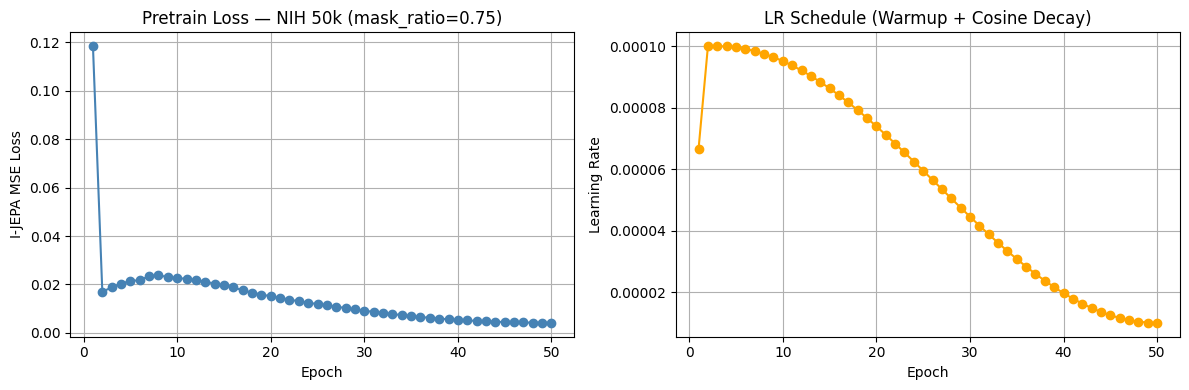

Saved: /kaggle/working/notebook03_ijepa_pretrain/figures/ijepa_pretrain_curves_50k.png


,epoch,avg_loss,lr,ema_momentum,subset,mask_ratio,batch_size,accumulation_steps
0,1,0.118464,0.000067,0.996000,50k,0.75,32,2
1,2,0.017017,0.000100,0.996004,50k,0.75,32,2
2,3,0.018727,0.000100,0.996016,50k,0.75,32,2
3,4,0.020327,0.000100,0.996035,50k,0.75,32,2
4,5,0.021416,0.000100,0.996063,50k,0.75,32,2
5,6,0.021761,0.000099,0.996098,50k,0.75,32,2
6,7,0.023386,0.000098,0.996140,50k,0.75,32,2
7,8,0.023794,0.000098,0.996190,50k,0.75,32,2
8,9,0.023019,0.000096,0.996247,50k,0.75,32,2
9,10,0.022600,0.000095,0.996311,50k,0.75,32,2


In [24]:
# ============================================================
# CELL 24: VẼ LOSS CURVE
# ============================================================

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(history_df["epoch"], history_df["avg_loss"], marker="o", color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("I-JEPA MSE Loss")
axes[0].set_title(f"Pretrain Loss — NIH {USE_SUBSET} (mask_ratio={MASK_RATIO})")
axes[0].grid(True)

# LR schedule
axes[1].plot(history_df["epoch"], history_df["lr"], marker="o", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].set_title("LR Schedule (Warmup + Cosine Decay)")
axes[1].grid(True)

plt.tight_layout()
loss_fig_path = FIG_DIR / f"ijepa_pretrain_curves_{USE_SUBSET}.png"
plt.savefig(loss_fig_path, dpi=200)
plt.show()
print("Saved:", loss_fig_path)

display(history_df)


In [25]:
# ============================================================
# CELL 25: KIỂM TRA FILE CHECKPOINT ĐÃ LƯU
# ============================================================

print("Files in checkpoint directory:")
for p in sorted(CKPT_DIR.glob("*")):
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name:60s}  ({size_mb:.1f} MB)")


Files in checkpoint directory:
  ijepa_vit_small_nih_50k_best.pth                              (370.6 MB)
  ijepa_vit_small_nih_50k_best_encoder.pth                      (86.7 MB)
  ijepa_vit_small_nih_50k_encoder_epoch_48.pth                  (86.7 MB)
  ijepa_vit_small_nih_50k_encoder_epoch_49.pth                  (86.7 MB)
  ijepa_vit_small_nih_50k_encoder_epoch_50.pth                  (86.7 MB)
  ijepa_vit_small_nih_50k_epoch_48.pth                          (370.6 MB)
  ijepa_vit_small_nih_50k_epoch_49.pth                          (370.6 MB)
  ijepa_vit_small_nih_50k_epoch_50.pth                          (370.6 MB)


In [26]:
# ============================================================
# CELL 26: VERIFY LOAD ENCODER CHECKPOINT
# ============================================================

best_enc_path = CKPT_DIR / f"ijepa_vit_small_nih_{USE_SUBSET}_best_encoder.pth"
assert best_enc_path.exists(), "Không tìm thấy best encoder checkpoint!"

test_encoder = build_vit_small_encoder(pretrained=False)
enc_ckpt     = torch.load(best_enc_path, map_location="cpu")
test_encoder.load_state_dict(enc_ckpt["encoder_state_dict"])

print("✓ Loaded encoder checkpoint successfully.")
print("  Checkpoint epoch  :", enc_ckpt["epoch"])
print("  Checkpoint loss   :", round(enc_ckpt["avg_loss"], 6))
print("  Config mask_ratio :", enc_ckpt["config"]["mask_ratio"])

del test_encoder
gc.collect()


✓ Loaded encoder checkpoint successfully.
  Checkpoint epoch  : 50
  Checkpoint loss   : 0.004101
  Config mask_ratio : 0.75


8

In [27]:
# ============================================================
# CELL 27: LƯU CONFIG PRETRAINING
# ============================================================

config_path = OUTPUT_DIR / f"ijepa_pretrain_config_{USE_SUBSET}.json"
with open(config_path, "w") as f:
    json.dump(pretrain_config, f, indent=2)
print("Saved config:", config_path)


Saved config: /kaggle/working/notebook03_ijepa_pretrain/ijepa_pretrain_config_50k.json


In [28]:
# ============================================================
# CELL 28: NÉN OUTPUT NOTEBOOK 03
# ============================================================

zip_base = "/kaggle/working/notebook03_ijepa_pretrain"
shutil.make_archive(zip_base, "zip", OUTPUT_DIR)
print("Created:", zip_base + ".zip")

print("\nDanh sách file output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(OUTPUT_DIR))


Created: /kaggle/working/notebook03_ijepa_pretrain.zip

Danh sách file output:
 - checkpoints/ijepa_vit_small_nih_50k_best.pth
 - checkpoints/ijepa_vit_small_nih_50k_best_encoder.pth
 - checkpoints/ijepa_vit_small_nih_50k_encoder_epoch_48.pth
 - checkpoints/ijepa_vit_small_nih_50k_encoder_epoch_49.pth
 - checkpoints/ijepa_vit_small_nih_50k_encoder_epoch_50.pth
 - checkpoints/ijepa_vit_small_nih_50k_epoch_48.pth
 - checkpoints/ijepa_vit_small_nih_50k_epoch_49.pth
 - checkpoints/ijepa_vit_small_nih_50k_epoch_50.pth
 - figures/ijepa_pretrain_curves_50k.png
 - ijepa_pretrain_config_50k.json
 - logs/ijepa_pretrain_history_50k.csv
